### Feature Analysis

####  *AUTHOR:* Ehsan Farahbakhsh
####  *CONTACT:* e.farahbakhsh@sydney.edu.au
####  *DATE last modified:* 16/09/2025

This notebook analyses the feature values extracted for positive samples (known mineral occurrences) and unlabelled samples, identifying the features that are highly correlated. Based on the provided metrics and visualisations, the user can decide which features to keep and which to remove. Using the selected features, we train a model with a positive–unlabelled bagging method to label the unlabelled samples. Finally, we use the positive samples and the newly labelled negative samples to generate histograms and violin plots, allowing us to compare the distribution of feature values between the two groups.

We begin by importing the required libraries:

In [1]:
# Import libraries
from ipywidgets import interact
import os

from gplately import EARTH_RADIUS
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pulearn import BaggingPuClassifier
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy import stats
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import IterativeImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real

# Note: Ensure the 'lib' folder is located in the same folder as this notebook
from lib.feature_analysis import *
from lib.feature_extraction import *

# Load configuration parameters (e.g., paths, model names)
from parameters import parameters

### Setup

As defined in `parameters.py`, the cell below configures the analysis parameters and specifies the paths to input/output files and directories. You can also specify the number of cores to use by setting an appropriate value for the `n_jobs` variable at the end of the cell.

**Note:** You can modify the analysis settings directly in `parameters.py`, which is structured as a dictionary and located in the same folder as this notebook.

In [2]:
buffer_distance = parameters["buffer_distance"]
num_random = parameters["num_random"]
columns_to_drop_deposit = parameters["columns_to_drop_deposit"]
columns_to_drop_unlabelled = parameters["columns_to_drop_unlabelled"]

# Directory paths for inputs and outputs
outputs_dir = parameters["outputs_dir"]
ml_dir = parameters["ml_dir"]

# Data filenames
deposit_data_filename = parameters["deposit_data_filename"]
unlabelled_data_filename = parameters["unlabelled_data_filename"]
features_imputed_weight_label_filename = parameters["features_imputed_weight_label_filename"]
corr_filename = parameters["corr_filename"]
Xy_train_original_filename = parameters["Xy_train_original_filename"]
Xy_pos_test_original_filename = parameters["Xy_pos_test_original_filename"]
Xy_train_filename = parameters["Xy_train_filename"]
Xy_pos_test_filename = parameters["Xy_pos_test_filename"]
Xy_train_new_filename = parameters["Xy_train_new_filename"]

robust_scaler_filename = parameters["robust_scaler_filename"]
model_pub_filename = parameters["model_pub_filename"]

# Construct full file/directory paths
ml_dir = os.path.join(outputs_dir, ml_dir)
if not os.path.exists(ml_dir):
    os.makedirs(ml_dir, exist_ok=True)

deposit_data_filename = os.path.join(outputs_dir, deposit_data_filename)
unlabelled_data_filename = os.path.join(outputs_dir, unlabelled_data_filename)
features_imputed_weight_label_filename = os.path.join(outputs_dir, features_imputed_weight_label_filename)
corr_filename = os.path.join(outputs_dir, corr_filename)
Xy_train_original_filename = os.path.join(ml_dir, Xy_train_original_filename)
Xy_pos_test_original_filename = os.path.join(ml_dir, Xy_pos_test_original_filename)
Xy_train_filename = os.path.join(ml_dir, Xy_train_filename)
Xy_pos_test_filename = os.path.join(ml_dir, Xy_pos_test_filename)
Xy_train_new_filename = os.path.join(ml_dir, Xy_train_new_filename)

robust_scaler_filename = os.path.join(ml_dir, robust_scaler_filename)
model_pub_filename = os.path.join(ml_dir, model_pub_filename)

# Number of cores to be used for running this notebook
n_jobs = 20

### Data Preparation

This cell merges the feature values for positive and negative samples into a single pandas DataFrame, which can then be used to analyse correlations between features. If the number of unlabeled samples is significantly higher than that of positive samples, they are downsampled to prevent model bias.

After combining the samples, we ensure that there are no missing values in the DataFrame. To achieve this, we apply an iterative imputer based on a Random Forest Regressor. This method predicts each missing value using patterns found in the other features, repeating the process iteratively to improve accuracy.

In [3]:
if os.path.isfile(features_imputed_weight_label_filename):
    features_imputed_weight_label = pd.read_csv(features_imputed_weight_label_filename)
else:
    deposit_data = pd.read_csv(deposit_data_filename)
    print("Number of deposits:", len(deposit_data))
    distance_threshold = np.deg2rad(buffer_distance) * EARTH_RADIUS
    count = (deposit_data["distance_to_trench (km)"] > distance_threshold).sum()
    print("Out of", len(deposit_data), "deposits", count, "are located further than the", int(distance_threshold), "km distance threshold.")
    unlabelled_data = pd.read_csv(unlabelled_data_filename)

    deposit_data["label"] = 1
    unlabelled_data["label"] = 0

    deposit_labels = deposit_data["label"]
    unlabelled_labels = unlabelled_data["label"]
    
    deposit_weights = deposit_data["weight"]
    unlabelled_weights = unlabelled_data["weight"]

    # Downsample unlabelled data points to avoid a biased model
    n_target = num_random * len(deposit_data)
    unlabelled_data_sampled = downsample(unlabelled_data, n_target=n_target, random_state=42)
    print("Number of unlabelled samples:", len(unlabelled_data_sampled))

    # Combine positive and unlabelled samples
    deposit_features = deposit_data.drop(columns=columns_to_drop_deposit)
    unlabelled_features_sampled = unlabelled_data_sampled.drop(columns=columns_to_drop_unlabelled)
    features_sampled = pd.concat([deposit_features, unlabelled_features_sampled], ignore_index=True)
    labels = pd.concat([deposit_labels, unlabelled_labels], ignore_index=True)
    weights = pd.concat([deposit_weights, unlabelled_weights], ignore_index=True)

    # Fill in missing values using an iterative imputer
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(random_state=42),
        random_state=42,
    )
    features_imputed_array = imputer.fit_transform(features_sampled)

    # Convert back to DataFrame with proper column names
    features_imputed = pd.DataFrame(features_imputed_array, columns=features_sampled.columns)
    features_imputed_weight_label = features_imputed.copy()
    features_imputed_weight_label["weight"] = weights
    features_imputed_weight_label["label"] = labels
    features_imputed_weight_label.to_csv(features_imputed_weight_label_filename, index=False)

features_imputed = features_imputed_weight_label.drop(["weight", "label"], axis=1)

### Correlation

This code snippet calculates the strength of feature correlations using the Spearman correlation coefficient, which is well-suited for detecting non-linear relationships. It then flags features with a correlation above 0.8—potentially indicating redundancy—and generates a report to support feature selection, helping reduce overlap and improve model interpretability.

In [4]:
if os.path.isfile(corr_filename):
    corr = pd.read_csv(corr_filename, index_col=0)
else:
    # Calculate Spearman correlation
    corr = features_imputed.corr(method="spearman").round(3)
    corr.to_csv(corr_filename, index=True)

# Identify highly correlated features
correlations = analyze_correlations(corr, threshold=0.8)
generate_report(correlations, threshold=0.8)

Correlation Analysis Report (Threshold: 0.8)

Feature: carbonate_thickness (m)
------------------------------
Positive Correlations:
  carbonate_carbon_density (t/m^2): 1.000
  subducted_carbonate_volume (m): 0.830

Feature: sedimentary_bound_water_thickness (m)
------------------------------
Positive Correlations:
  sedimentary_pore_water_thickness (m): 1.000
  sediment_thickness (m): 1.000
  total_water_thickness (m): 0.856

Feature: total_water_thickness (m)
------------------------------
Positive Correlations:
  sedimentary_bound_water_thickness (m): 0.856
  sedimentary_pore_water_thickness (m): 0.856
  sediment_thickness (m): 0.856

Feature: subducted_carbon_density (t/m^2)
------------------------------
Positive Correlations:
  subducted_plate_volume (m): 0.982
  subducted_water_volume (m): 0.976
  subducted_sediment_volume (m): 0.949

Feature: seafloor_spreading_rate (km/Myr)
------------------------------
Negative Correlations:
  mantle_lithosphere_water_thickness (m): -1.000
 

### Dendrogram

This code snippet groups together features that exhibit similar patterns across the dataset. It uses Spearman correlation to measure the strength of correlation between features, then applies hierarchical clustering to group those that are strongly correlated. A dendrogram (tree diagram) is plotted to visualise these relationships, with a red dashed line indicating the correlation cutoff. This helps identify redundant features that can be removed or combined, simplifying the modelling process.

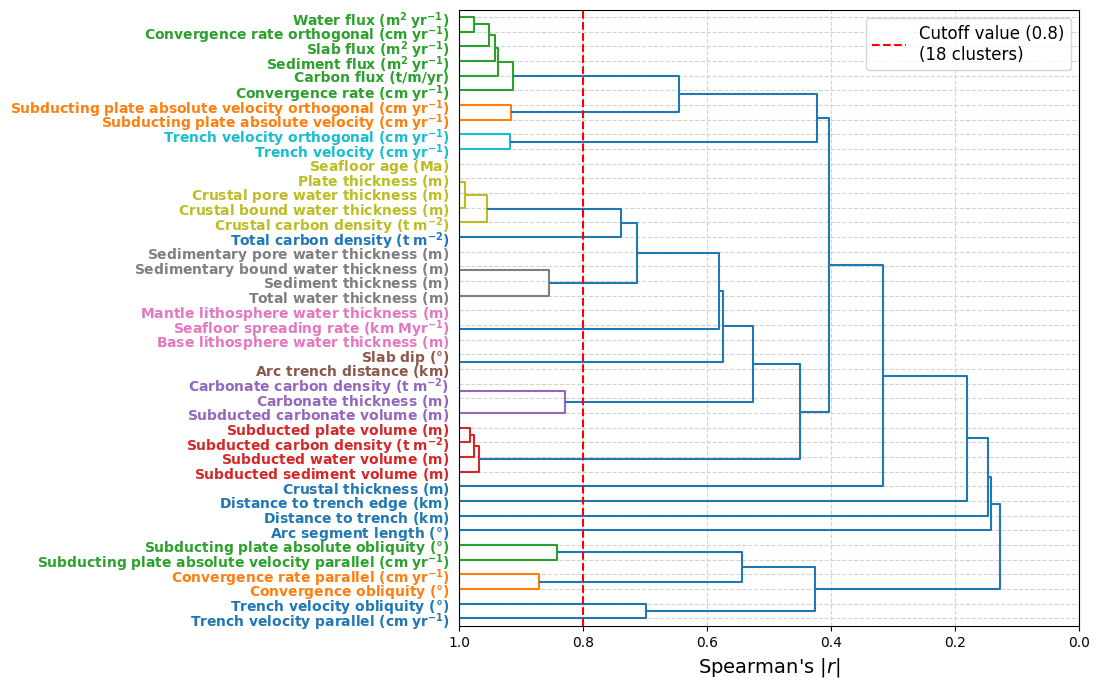

In [5]:
cutoff_value = 0.8
cluster_threshold = 1 - cutoff_value

# Hierarchical clustering of geological features
Z = linkage(
    features_imputed.T,
    method="single",
    metric=lambda x, y: 1.0 - np.abs(spearmanr(x, y).statistic),
)

# Identify feature clusters
cluster_ids = fcluster(Z, cluster_threshold, criterion="distance")
clusters = {
    cluster_id: list(features_imputed.columns[cluster_ids == cluster_id])
    for cluster_id in np.unique(cluster_ids)
}

# Create a dendrogram showing correlations
fig, ax = plt.subplots(figsize=(8, 8))
dendro = dendrogram(
    Z,
    orientation="right",
    labels=[format_feature_name(i, bold=True) for i in features_imputed.columns],
    ax=ax,
    color_threshold=cluster_threshold,
)
ax.axvline(
    cluster_threshold,
    linestyle="dashed",
    color="red",
    zorder=10,
    label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} clusters)",
)
ax.grid(linestyle="dashed", color="lightgrey")
ax.set_xticks(ax.get_xticks(), [f"{1 - i:0.1f}" for i in ax.get_xticks()])
ax.set_xlabel(r"Spearman's $|r|$", fontsize=14)
ax.tick_params(labelsize=10)
for i, j in zip(ax.get_ymajorticklabels(), dendro["leaves_color_list"]):
    i.set_color(j)
    i.set_fontweight("bold")
ax.legend(loc="best", fontsize=12)

This code snippet prints the feature groups identified during the clustering process. Each cluster contains highly correlated features, making it easy to spot those that provide overlapping information.

In [6]:
for cluster_id in sorted(clusters.keys()):
    cluster_features = clusters[cluster_id]
    print(f"Cluster #{cluster_id}:")
    for feature in cluster_features:
        print(f"  - {feature}")

Cluster #1:
  - trench_velocity_parallel (cm/yr)
Cluster #2:
  - trench_velocity_obliquity (degrees)
Cluster #3:
  - convergence_obliquity (degrees)
  - convergence_rate_parallel (cm/yr)
Cluster #4:
  - subducting_plate_absolute_velocity_parallel (cm/yr)
  - subducting_plate_absolute_obliquity (degrees)
Cluster #5:
  - subducted_carbon_density (t/m^2)
  - subducted_sediment_volume (m)
  - subducted_water_volume (m)
  - subducted_plate_volume (m)
Cluster #6:
  - carbonate_thickness (m)
  - subducted_carbonate_volume (m)
  - carbonate_carbon_density (t/m^2)
Cluster #7:
  - arc_trench_distance (km)
  - slab_dip (degrees)
Cluster #8:
  - seafloor_spreading_rate (km/Myr)
  - mantle_lithosphere_water_thickness (m)
  - base_lithosphere_water_thickness (m)
Cluster #9:
  - sedimentary_bound_water_thickness (m)
  - total_water_thickness (m)
  - sedimentary_pore_water_thickness (m)
  - sediment_thickness (m)
Cluster #10:
  - plate_thickness (m)
  - crustal_bound_water_thickness (m)
  - crustal_po

This plot illustrates how the number of feature clusters varies as the correlation cutoff changes. We test cutoff values ranging from 0 to 1 to observe how stricter or looser thresholds affect feature grouping. The blue line shows the number of distinct clusters that remain at each cutoff value, while the red dashed line marks the selected cutoff (0.8) and its corresponding number of clusters. This visualisation helps determine an appropriate threshold for grouping features based on their similarity.

Text(0, 0.5, 'Number of remaining features')

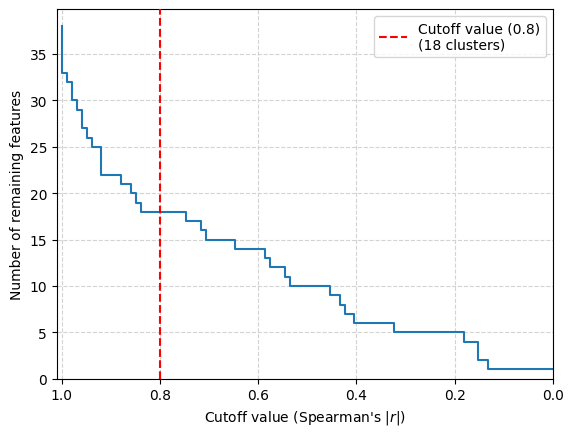

In [7]:
thresh_vals = np.linspace(0, 1, 100)
thresh_clusters = np.array([
    len(np.unique(fcluster(Z, 1 - t, criterion="distance")))
    for t in thresh_vals
])

fig, ax = plt.subplots()
ax.step(thresh_vals, thresh_clusters, where="post")
ax.axvline(
    cutoff_value,
    linestyle="dashed",
    color="red",
    zorder=10,
    label=f"Cutoff value ({cutoff_value:0.1f})\n({len(clusters)} clusters)",
)
ax.set_xlim(thresh_vals.max() * 1.01, thresh_vals.min())
ax.set_ylim(0, None)
ax.grid(linestyle="dashed", color="lightgrey")
ax.legend(loc="best")
ax.set_xlabel(r"Cutoff value (Spearman's $|r|$)")
ax.set_ylabel("Number of remaining features")

### Feature Selection

The list below highlights the key features selected to best represent subduction zone processes. Features that were not used are commented out. To avoid redundancy and confounding effects, one representative feature was chosen from each highly correlated cluster.

In [8]:
selected_features = [
#     "arc_segment_length (degrees)",
#     "arc_trench_distance (km)",
#     "base_lithosphere_water_thickness (m)",
#     "carbon_flux (t/m/yr)",
#     "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "convergence_obliquity (degrees)",
    "convergence_rate (cm/yr)",
#     "convergence_rate_orthogonal (cm/yr)",
#     "convergence_rate_parallel (cm/yr)",
#     "crustal_bound_water_thickness (m)",
#     "crustal_carbon_density (t/m^2)",
#     "crustal_pore_water_thickness (m)",
    "crustal_thickness (m)",
#     "distance_from_trench_start (km)",
    "distance_to_trench (km)",
    "distance_to_trench_edge (km)",
#     "mantle_lithosphere_water_thickness (m)",
#     "plate_thickness (m)",
    "seafloor_age (Ma)",
    "seafloor_spreading_rate (km/Myr)",
#     "sediment_flux (m^2/yr)",
    "sediment_thickness (m)",
#     "sedimentary_bound_water_thickness (m)",
#     "sedimentary_pore_water_thickness (m)",
    "slab_dip (degrees)",
#     "slab_flux (m^2/yr)",
#     "subducted_carbon_density (t/m^2)",
#     "subducted_carbonate_volume (m)",
#     "subducted_plate_volume (m)",
    "subducted_sediment_volume (m)",
#     "subducted_water_volume (m)",
    "subducting_plate_absolute_obliquity (degrees)",
    "subducting_plate_absolute_velocity (cm/yr)",
#     "subducting_plate_absolute_velocity_orthogonal (cm/yr)",
#     "subducting_plate_absolute_velocity_parallel (cm/yr)",
    "total_carbon_density (t/m^2)",
#     "total_water_thickness (m)",
#     "trench_normal_angle (degrees)",
    "trench_velocity (cm/yr)",
    "trench_velocity_obliquity (degrees)",
#     "trench_velocity_orthogonal (cm/yr)",
    "trench_velocity_parallel (cm/yr)",
#     "water_flux (m^2/yr)",
]

### Train-Test Split

Here, we prepare the data for training and testing the positive-unlabelled bagging model used to label the unlabelled samples. The positive samples are split into two groups: one for training the model and the other for evaluating its performance. We then combine the unlabelled data with the training set and apply a Robust Scaler to the features to reduce the influence of outliers. This ensures fair treatment of all features and helps the model learn more effectively.

In [9]:
selected_features_weight = selected_features.copy()
selected_features_weight.append("weight")

if os.path.isfile(robust_scaler_filename):
    robust_scaler = joblib.load(robust_scaler_filename)
    Xy_train_original = pd.read_csv(Xy_train_original_filename)
    Xy_train = pd.read_csv(Xy_train_filename)
    Xy_pos_test = pd.read_csv(Xy_pos_test_filename)
else:
    deposit_features_imputed_weight_label = features_imputed_weight_label[features_imputed_weight_label["label"] == 1]
    unlabelled_features_imputed_weight_label = features_imputed_weight_label[features_imputed_weight_label["label"] == 0]

    deposit_features_imputed_weight = deposit_features_imputed_weight_label[selected_features_weight]
    unlabelled_features_imputed_weight = unlabelled_features_imputed_weight_label[selected_features_weight]

    deposit_labels = deposit_features_imputed_weight_label["label"]
    unlabelled_labels = unlabelled_features_imputed_weight_label["label"]

    # Split positive samples into train and test datasets
    X_pos_train, X_pos_test, y_pos_train, y_pos_test = train_test_split(deposit_features_imputed_weight, deposit_labels, train_size=0.8, random_state=42)
    # Combine training positive samples with unlabelled samples
    X_train = np.vstack((X_pos_train, unlabelled_features_imputed_weight))
    y_train = np.vstack((y_pos_train.values.reshape(-1, 1), unlabelled_labels.values.reshape(-1, 1)))

    selected_features_weight_label = selected_features_weight.copy()
    selected_features_weight_label.append("label")

    # Save original (unscaled) training data
    Xy_train_original = np.hstack((X_train, y_train))
    Xy_train_original = pd.DataFrame(Xy_train_original, columns=selected_features_weight_label)
    Xy_train_original.to_csv(Xy_train_original_filename, index=False)

    Xy_train_features = Xy_train_original[selected_features]
    Xy_train_labels = Xy_train_original["label"]
    Xy_train_weights = Xy_train_original["weight"]

    # Scale features to mitigate outliers
    # RobustScaler is less sensitive to outliers than standard scaling
    robust_scaler = RobustScaler()
    X_train = robust_scaler.fit_transform(Xy_train_features)
    Xy_train = np.hstack((X_train, Xy_train_weights.values.reshape(-1, 1), Xy_train_labels.values.reshape(-1, 1)))
    Xy_train = pd.DataFrame(Xy_train, columns=selected_features_weight_label)
    Xy_train.to_csv(Xy_train_filename, index=False)

    Xy_pos_test_original = np.hstack((X_pos_test, y_pos_test.values.reshape(-1, 1)))
    Xy_pos_test_original = pd.DataFrame(Xy_pos_test_original, columns=selected_features_weight_label)
    Xy_pos_test_original.to_csv(Xy_pos_test_original_filename, index=False)

    Xy_pos_test_features = Xy_pos_test_original[selected_features]
    Xy_pos_test_labels = Xy_pos_test_original["label"]
    Xy_pos_test_weights = Xy_pos_test_original["weight"]

    # Apply same scaling to test data
    X_pos_test = robust_scaler.transform(Xy_pos_test_features)
    Xy_pos_test = np.hstack((X_pos_test, Xy_pos_test_weights.values.reshape(-1, 1), Xy_pos_test_labels.values.reshape(-1, 1)))
    Xy_pos_test = pd.DataFrame(Xy_pos_test, columns=selected_features_weight_label)
    Xy_pos_test.to_csv(Xy_pos_test_filename, index=False)

    # Save the scaler for future use
    joblib.dump(robust_scaler, robust_scaler_filename)
    
    print("Number of positive training samples:", X_pos_train.shape[0])
    print("Number of unlabelled training samples:", unlabelled_features_imputed_weight.shape[0])
    print("Number of positive testing samples:", X_pos_test.shape[0])

### Positive-Unlabelled Bagging

We have data points that are confirmed positive, while the rest of the dataset remains unlabelled — not explicitly negative, but simply unknown. To handle this, we apply positive-unlabelled bagging.

The aim of this code snippet is to identify the most effective model for distinguishing hidden positives from unlabelled samples. Once identified, these hidden positives will be later removed, leaving only those samples that can be considered negative.

For this task, we use Random Forest as the estimator, as it is well-suited to the complexity of our dataset. To optimise performance, we apply Bayesian Optimisation, which efficiently explores hyperparameter combinations to find the best configuration based on the F1-score — balancing the detection of true positives while minimising false positives. Finally, we use cross-validation to ensure the model's robustness and generalisability.

In [10]:
features_pub = Xy_train[[col for col in Xy_train.columns if col not in ["weight", "label"]]]
labels_pub = Xy_train["label"]
weights_pub = Xy_train["weight"]

if os.path.isfile(model_pub_filename):
    # Load previously trained model if available
    model_pub = joblib.load(model_pub_filename)
else:
    # Random Forest model structure
    rf_pub = RandomForestClassifier(n_jobs=n_jobs, random_state=42)
    pub = BaggingPuClassifier(rf_pub, n_jobs=n_jobs, random_state=42)

    n_fold = 10 # Number of cross-validation folds

    search_space = {
    "estimator__bootstrap": Categorical([True, False]),
    "estimator__max_depth": Integer(5, 20),
    "estimator__max_features": Categorical([None, "sqrt","log2"]), 
    "estimator__min_samples_leaf": Integer(2, 20),
    "estimator__min_samples_split": Integer(2, 30),
    "estimator__n_estimators": Integer(10, 200),
    "max_samples": Integer(int(0.5*(len(labels_pub)-sum(labels_pub))), int(0.9*(len(labels_pub)-sum(labels_pub))))
    }

    # Perform Bayesian optimisation for hyperparameter tuning
    pub_bayes_search = BayesSearchCV(pub,
                                     search_space,
                                     n_iter=50, # Specify how many iterations
                                     scoring="f1", # Use F1 score for evaluation
                                     n_jobs=n_jobs,
                                     cv=n_fold,
                                     verbose=1,
                                     random_state=42)
    pub_bayes_search.fit(features_pub, labels_pub, sample_weight=weights_pub)
    
    # Extract the optimisation results and best model
    optimization_results = pub_bayes_search.cv_results_["mean_test_score"]
    
    model_pub = pub_bayes_search.best_estimator_
    model_pub_f1 = pub_bayes_search.best_score_    
    print("The highest F1-score during cross validation:", model_pub_f1)
    
    # Save the model
    joblib.dump(model_pub, model_pub_filename)
    
    # Plot the Bayesian optimisation progress
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(optimization_results) + 1), optimization_results, marker="o", color="black", markerfacecolor="red")
    plt.xlim(0, len(optimization_results) + 1)
    plt.xlabel("Bayesian Optimisation Iteration")
    plt.ylabel("Mean Test F1 Score")
    plt.title("Bayesian Optimisation Progress")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

After training the positive-unlabelled bagging model, we evaluate its performance using known positive samples that were not included during training. The model is applied to these test samples to predict which ones it recognises as positive, and we then measure the accuracy of these predictions.

In [11]:
# Test on held-out positive samples
X_pos_test = Xy_pos_test[[col for col in Xy_pos_test.columns if col not in ["weight", "label"]]]
y_pos_test = Xy_pos_test["label"]
weights_pos_test = Xy_pos_test["weight"]

# Make predictions on test samples
X_pos_pred = model_pub.predict(X_pos_test)
X_pos_pred_acc = accuracy_score(y_pos_test, X_pos_pred, sample_weight=weights_pos_test)
print("Accuracy:", X_pos_pred_acc)

Accuracy: 0.8638814016172507


We use the trained model to refine and expand the dataset by identifying additional potential positive and negative samples. In practice, the model predicts whether each unlabelled site is likely to be positive.

Each data point is then re-labelled as follows:  
- **0** for likely negative  
- **1** for confirmed positive (known mineral occurrences)  
- **2** for newly predicted positive (flagged by the model as potentially positive)  

The updated dataset is then saved for future use.

In [12]:
if os.path.isfile(Xy_train_new_filename):
    # Load previously generated new training data if available
    Xy_train_new = pd.read_csv(Xy_train_new_filename)
else:
    # Apply model
    labels_pred = model_pub.predict(features_pub)
    
    labels_new = []
    for real, pred in zip(labels_pub, labels_pred):
        if real == 1:
            labels_new.append(1) # Known mineral occurrences
        elif pred == 1:
            labels_new.append(2) # Predicted favourable from unlabelled data
        else:
            labels_new.append(0) # # Negative prediction

    # Save results with updated labels
    Xy_train_new = features_pub.copy()
    Xy_train_new["weight"] = weights_pub
    Xy_train_new["label"] = labels_new
    Xy_train_new.to_csv(Xy_train_new_filename, index=False)

### Histogram

We filter the dataset to include only real positive samples and negative samples identified by the PUB model. An interactive, side-by-side histogram is then generated for any chosen feature, allowing comparison of the feature value distributions between positive and negative samples.

In [13]:
# Filer out uncertain predictions
Xy_train_new_filtered = Xy_train_new[Xy_train_new["label"] != 2]
Xy_train_new_filtered_labels = Xy_train_new_filtered["label"]
Xy_train_new_filtered = Xy_train_new_filtered.drop(["weight", "label"], axis=1)
Xy_train_new_filtered_original_values = Xy_train_new_filtered * robust_scaler.scale_ + robust_scaler.center_
Xy_train_new_filtered_original_values["label"] = Xy_train_new_filtered_labels

# Separate the data by label
negatives = Xy_train_new_filtered_original_values[Xy_train_new_filtered_original_values["label"] == 0]
positives = Xy_train_new_filtered_original_values[Xy_train_new_filtered_original_values["label"] == 1]

@interact
def show_hist(feature=selected_features):
    # Create the plot
    fig, ax = plt.subplots()
    ax.set_facecolor("whitesmoke")

    # Histogram for negatives
    counts_neg, bins, _ = ax.hist(negatives[feature], bins=30, facecolor="LightSalmon", edgecolor="black", 
            label="Negative", density=True, alpha=1)

    # Histogram for positives
    counts_pos, _, _ = ax.hist(positives[feature], bins=bins, facecolor="DarkSeaGreen", edgecolor="black", 
            label="Positive", density=True, alpha=0.6)

    # Labels and legend
    ax.set_xlabel(format_feature_name(feature))
    ax.set_ylabel("Probability Density")
    ax.legend(loc="best")

    fig.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('carbonate_thickness (m)', 'convergence_obliqui…

### Violin-Box Plot

We provide another interactive method to visually compare the distributions of any selected feature between real positive samples and negative samples. This visualisation combines violin plots, which display the full distribution, with box plots, which highlight medians, ranges, and outliers.

In [14]:
labels = Xy_train_new_filtered_original_values["label"].unique()

@interact
def show_violin_box(feature=selected_features):
    # Collect values for the selected feature, grouped by label
    plot_data = [Xy_train_new_filtered_original_values[Xy_train_new_filtered_original_values["label"] == label][feature] for label in labels]
    
    fig, ax = plt.subplots()
    ax.set_facecolor("whitesmoke")
    
    colors = ["DarkSeaGreen", "LightSalmon"]
    
    # Draw violin plot (distribution shape)
    vplot_parts = ax.violinplot(plot_data, positions=np.arange(len(labels)))
    for i, body in enumerate(vplot_parts["bodies"]):
        body.set_facecolor(colors[i])
        body.set_edgecolor(colors[i])
    for partname in ("cbars", "cmins", "cmaxes"):
        vp = vplot_parts.get(partname)
        if vp:
            vp.set_edgecolor("black")
    
    # Draw boxplot over violin for statistical summary
    bp = ax.boxplot(plot_data, positions=np.arange(len(labels)), patch_artist=True,
                    whis=(5, 95), widths=0.2,
                    flierprops=dict(marker=".", markersize=8, markerfacecolor="red", markeredgecolor="black"),
                    medianprops=dict(color="black", linewidth=1.5),
                    whiskerprops=dict(color="black", linestyle="-"),
                    capprops=dict(color="none"))  # "hide" caps
    
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    
    ax.set_xticklabels(["Positive", "Negative"])
    ax.set_ylabel(format_feature_name(feature))
    
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='feature', options=('carbonate_thickness (m)', 'convergence_obliqui…